In [1]:
import torch
import hdf5plugin
import h5py
from omegaconf import OmegaConf

from transformers import AutoImageProcessor, AutoModel

from sequence_compression.module import JEPA, ARPredictor, Transpressor

from tqdm import tqdm

from matplotlib import pyplot as plt

In [2]:
def build_jepa(config, checkpoint, device):
    pixel_encoder = AutoModel.from_pretrained(config.pixel_encoder.model_name)

    action_encoder = Transpressor(
        input_dim=config.frameskip * config.transpressor.input_dim,
        hidden_dim=config.transpressor.hidden_dim,
        condition_dim=config.transpressor.condition_dim,
        depth=config.transpressor.depth,
        heads=config.transpressor.heads,
        dim_head=config.transpressor.dim_head,
        mlp_dim=config.transpressor.mlp_dim,
        sequence_dim=config.max_hop_length + 1,
        output_proj=config.transpressor.output_proj,
    )

    predictor = ARPredictor(
        input_dim=pixel_encoder.config.hidden_size,
        hidden_dim=config.ar_predictor.hidden_dim,
        condition_dim=config.ar_predictor.condition_dim,
        depth=config.ar_predictor.depth,
        heads=config.ar_predictor.heads,
        dim_head=config.ar_predictor.dim_head,
        mlp_dim=config.ar_predictor.mlp_dim,
        dropout=config.ar_predictor.dropout,
        sequence_dim=config.num_frames - 1,
        out_proj=config.transpressor.output_proj,
    )

    model = JEPA(pixel_encoder=pixel_encoder, action_encoder=action_encoder, predictor=predictor)
    state_dict = torch.load(checkpoint, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    return model.to(device).eval()

h5_path = "../data/pusht_expert_train.h5"
config_path = "../config/transpressor_v2.yaml"
checkpoint = "../checkpoints/lewm_epoch_1.pt"
device = "mps"

config = OmegaConf.load(config_path)
jepa = build_jepa(config, checkpoint, device)
preprocessor = AutoImageProcessor.from_pretrained(config.pixel_preprocessor.model_name)



Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

torch.Size([200, 2, 10])
torch.Size([200, 1, 64])
torch.Size([64, 64])
2.6431005


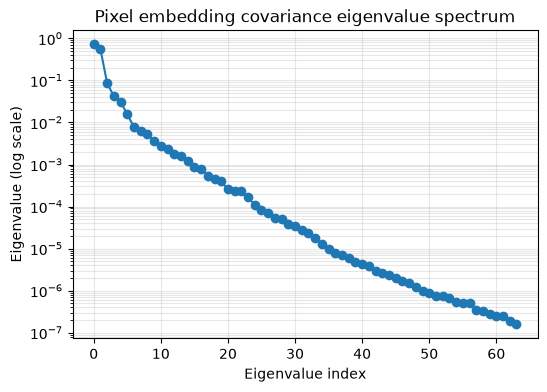

In [3]:
import logging
import evotorch
from evotorch.algorithms import CEM
import numpy as np
import torch
from einops import rearrange

logging.getLogger("evotorch").setLevel(logging.WARNING)

with torch.no_grad():
    with h5py.File(h5_path, "r") as data:
        # Sample 100 unique datapoints from dataset
        embeddings = []

        action_arr = data["action"][:]  # load once; h5py fancy-indexing per-row is slow
        #  pixels_arr = data["pixels"][:]
        starts = np.random.randint(0, len(action_arr) - 10, size=200)
        actions = torch.tensor(np.stack([action_arr[s:s + 10] for s in starts])).to("mps")  # (200, 10, 2)

    # Bundle every frameskip=5 consecutive raw actions into one macro-step, concatenated
    # along the feature axis (mirrors ChainDataset's frameskip bundling): (B, 10, 2) -> (B, 2, 10).
    frameskip = 5
    raw_B, raw_T, action_dim = actions.shape
    actions = actions.reshape(raw_B, raw_T // frameskip, frameskip * action_dim)

    print(actions.shape)
    B, T, D = actions.shape

    start = torch.full((B, 1, D), -2, device="mps")
    end = torch.full((B, 1, D), -3, device="mps")

    starts = np.random.randint(0, len(action_arr) - 10, size=200)
    # pixels = torch.tensor(np.stack([pixels_arr[s:s + 10] for s in starts])).to("mps")

    # PB, PT, C, H, W = pixels.shape

    final = torch.cat([start, actions, end], dim=1).to("mps")

    # print(pixels.shape)
    embs = jepa.encode_actions(final)

    # pixels = pixels.reshape(PB*PT, C, H, W).to(torch.uint8).cpu().numpy()
    # pixels = preprocessor(list(pixels), return_tensors="pt")["pixel_values"].to("mps")

    # pixels = rearrange(pixels, "(b t) c h w -> b t c h w", b=PB, t=PT)
    # pixel_embs = jepa.encode_pixels(pixels)

    print(embs.shape)

    action_feats = embs.squeeze(1)                              # (B, D_cond) - one row per sample
    # pixel_feats = pixel_embs.reshape(-1, pixel_embs.shape[-1])   # (PB*PT, D_pix) - one row per frame

    # torch.cov expects (features, observations); our tensors are (observations, features), so transpose
    cov = torch.cov(action_feats.T)
    # pixel_cov = torch.cov(pixel_feats.T)

    print(cov.shape)

    vals, vecs = torch.linalg.eigh(cov.cpu())
    # p_val, p_vec = torch.linalg.eigh(pixel_cov.cpu())

    vals = vals.numpy()[::-1]  # descending, largest first
    # p_val = p_val.numpy()[::-1]

    r_eff = r_eff = (vals.sum())**2 / (vals**2).sum()
    print(r_eff)

plt.figure(figsize=(6,4))
plt.plot(vals, marker='o')
plt.yscale('log')
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Pixel embedding covariance eigenvalue spectrum")
plt.grid(True, which="both", alpha=0.3)
plt.show()

torch.Size([200, 10, 224, 224, 3])
torch.Size([384, 384])
6.45984


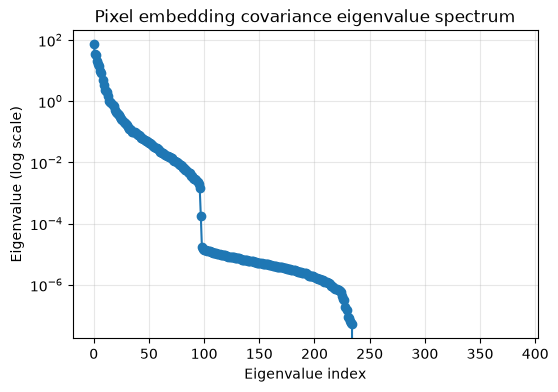

In [4]:
import logging
import evotorch
from evotorch.algorithms import CEM
import numpy as np
import torch
from einops import rearrange

logging.getLogger("evotorch").setLevel(logging.WARNING)

with torch.no_grad():
    with h5py.File(h5_path, "r") as data:
        # Sample 100 unique datapoints from dataset
        embeddings = []

        #action_arr = data["action"][:]  # load once; h5py fancy-indexing per-row is slow
        pixels_arr = data["pixels"][:100]
        starts = np.random.randint(0, len(pixels_arr) - 10, size=200)
        # actions = torch.tensor(np.stack([action_arr[s:s + 10] for s in starts])).to("mps")  # (200, 10, 2)

    # Bundle every frameskip=5 consecutive raw actions into one macro-step, concatenated
    # along the feature axis (mirrors ChainDataset's frameskip bundling): (B, 10, 2) -> (B, 2, 10).
    # frameskip = 5
    # raw_B, raw_T, action_dim = actions.shape
    # actions = actions.reshape(raw_B, raw_T // frameskip, frameskip * action_dim)

    # print(actions.shape)
    # B, T, D = actions.shape

    # start = torch.full((B, 1, D), -2, device="mps")
    # end = torch.full((B, 1, D), -3, device="mps")

    # starts = np.random.randint(0, len(action_arr) - 10, size=200)
    pixels = torch.tensor(np.stack([pixels_arr[s:s + 10] for s in starts])).to("mps")

    PB, PT, C, H, W = pixels.shape

    # final = torch.cat([start, actions, end], dim=1).to("mps")

    print(pixels.shape)
    # embs = jepa.encode_actions(final)

    pixels = pixels.reshape(PB*PT, C, H, W).to(torch.uint8).cpu().numpy()
    pixels = preprocessor(list(pixels), return_tensors="pt")["pixel_values"].to("mps")

    pixels = rearrange(pixels, "(b t) c h w -> b t c h w", b=PB, t=PT)
    pixel_embs = jepa.encode_pixels(pixels)

    # print(embs.shape)

    # action_feats = embs.squeeze(1)                              # (B, D_cond) - one row per sample
    pixel_feats = pixel_embs.reshape(-1, pixel_embs.shape[-1])   # (PB*PT, D_pix) - one row per frame

    # torch.cov expects (features, observations); our tensors are (observations, features), so transpose
    # cov = torch.cov(action_feats.T)
    pixel_cov = torch.cov(pixel_feats.T)

    print(pixel_cov.shape)

    # vals, vecs = torch.linalg.eigh(cov.cpu())
    p_val, p_vec = torch.linalg.eigh(pixel_cov.cpu())

    # vals = vals.numpy()[::-1]  # descending, largest first
    p_val = p_val.numpy()[::-1]

    r_eff = r_eff = (p_val.sum())**2 / (p_val**2).sum()
    print(r_eff)

plt.figure(figsize=(6,4))
plt.plot(p_val, marker='o')
plt.yscale('log')
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue (log scale)")
plt.title("Pixel embedding covariance eigenvalue spectrum")
plt.grid(True, which="both", alpha=0.3)
plt.show()